# MCal Results Visualization - All Datasets

This notebook plots the results from Table 1 showing the performance of different calibration methods across all datasets, organized by modality.

In [ ]:
import json
import matplotlib.pyplot as plt
import numpy as np
import os

## Vision Modality

### Brain MRI Dataset

In [ ]:
# Load MRI results
with open('../results/json/aggregated_results_mri.json', 'r') as f:
    mri_results = json.load(f)

# Define method names and labels for MRI
mri_methods = {
    'baseline': 'Original',
    'replace_mean': 'Replace',
    'patchcutout': 'PatchCutout',
    'platt': 'Platt',
    'arch_mod': 'Arch Mod',
    'mcal_ce': 'MCal CE'
}

# Extract data for each method
mri_data = {}
for key, label in mri_methods.items():
    if key in mri_results:
        if key == 'baseline':
            mri_data[label] = mri_results[key]['fraction_wise_results']['mean_argmax']
        else:
            mri_data[label] = mri_results[key]['fraction_wise_results_transformed']['mean_argmax']

# Create x-axis (fraction values)
n_points = len(next(iter(mri_data.values())))
fractions = np.linspace(0, 1, n_points)

### BreakHis Dataset

In [23]:
# Load BreakHis results
breakhis_path = '../experiments/vision/results/json/aggregated_results_breakhis.json'
if os.path.exists(breakhis_path):
    with open(breakhis_path, 'r') as f:
        breakhis_results = json.load(f)

    # Define method names and labels for BreakHis
    breakhis_methods = {
        'baseline': 'Original',
        'replace_mean': 'Replace',
        'patchcutout': 'PatchCutout',
        'temperature': 'Temperature',
        'platt': 'Platt',
        'arch_mod': 'Arch Mod',
        'mcal_ce': 'MCal CE'
    }

    # Extract data for each method (only include methods that exist in results)
    breakhis_data = {}
    for key, label in breakhis_methods.items():
        if key in breakhis_results:
            if key == 'baseline':
                breakhis_data[label] = breakhis_results[key]['fraction_wise_results']['mean_argmax']
            else:
                breakhis_data[label] = breakhis_results[key]['fraction_wise_results_transformed']['mean_argmax']

    # Create x-axis (fraction values)
    if breakhis_data:
        n_points = len(next(iter(breakhis_data.values())))
        fractions = np.linspace(0, 1, n_points)
else:
    print(f"BreakHis results not found at {breakhis_path}")
    breakhis_data = None

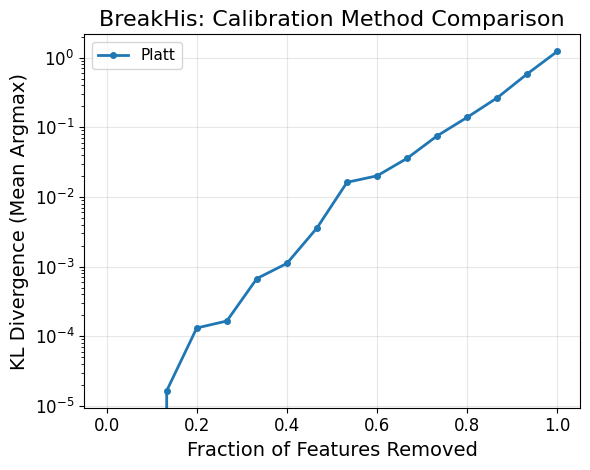


BreakHis - Summary Statistics (Mean KL Divergence across all fractions):
Platt          : 0.148621


In [24]:
# Plot BreakHis results
if breakhis_data:
    plt.figure(figsize=(6, 4.8))

    for label, values in breakhis_data.items():
        plt.plot(fractions, values, marker='o', label=label, linewidth=2, markersize=4)

    plt.xlabel('Fraction of Features Removed', fontsize=14)
    plt.ylabel('KL Divergence (Mean Argmax)', fontsize=14)
    plt.title('BreakHis: Calibration Method Comparison', fontsize=16)
    plt.yscale('log')
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tick_params(labelsize=12)
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print("\nBreakHis - Summary Statistics (Mean KL Divergence across all fractions):")
    print("="*60)
    for label, values in breakhis_data.items():
        mean_kl = np.mean(values)
        print(f"{label:15s}: {mean_kl:.6f}")
else:
    print("No BreakHis data to plot")

### CheXpert Dataset

In [25]:
# Load CheXpert results
chexpert_path = '../experiments/vision/results/json/aggregated_results_chexpert.json'
if os.path.exists(chexpert_path):
    with open(chexpert_path, 'r') as f:
        chexpert_results = json.load(f)

    # Define method names and labels for CheXpert
    chexpert_methods = {
        'baseline': 'Original',
        'replace_mean': 'Replace',
        'patchcutout': 'PatchCutout',
        'temperature': 'Temperature',
        'platt': 'Platt',
        'arch_mod': 'Arch Mod',
        'mcal_ce': 'MCal CE'
    }

    # Extract data for each method (only include methods that exist in results)
    chexpert_data = {}
    for key, label in chexpert_methods.items():
        if key in chexpert_results:
            if key == 'baseline':
                chexpert_data[label] = chexpert_results[key]['fraction_wise_results']['mean_argmax']
            else:
                chexpert_data[label] = chexpert_results[key]['fraction_wise_results_transformed']['mean_argmax']

    # Create x-axis (fraction values)
    if chexpert_data:
        n_points = len(next(iter(chexpert_data.values())))
        fractions = np.linspace(0, 1, n_points)
else:
    print(f"CheXpert results not found at {chexpert_path}")
    chexpert_data = None

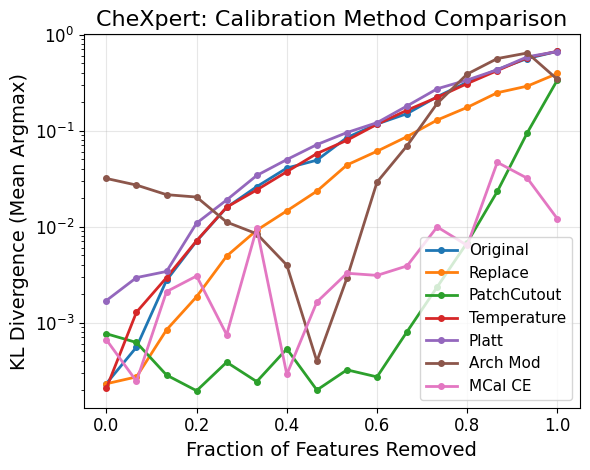


CheXpert - Summary Statistics (Mean KL Divergence across all fractions):
Original       : 0.169003
Replace        : 0.092620
PatchCutout    : 0.029377
Temperature    : 0.168969
Platt          : 0.180184
Arch Mod       : 0.147105
MCal CE        : 0.008458


In [26]:
# Plot CheXpert results
if chexpert_data:
    plt.figure(figsize=(6, 4.8))

    for label, values in chexpert_data.items():
        plt.plot(fractions, values, marker='o', label=label, linewidth=2, markersize=4)

    plt.xlabel('Fraction of Features Removed', fontsize=14)
    plt.ylabel('KL Divergence (Mean Argmax)', fontsize=14)
    plt.title('CheXpert: Calibration Method Comparison', fontsize=16)
    plt.yscale('log')
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.tick_params(labelsize=12)
    plt.tight_layout()
    plt.show()

    # Summary statistics
    print("\nCheXpert - Summary Statistics (Mean KL Divergence across all fractions):")
    print("="*60)
    for label, values in chexpert_data.items():
        mean_kl = np.mean(values)
        print(f"{label:15s}: {mean_kl:.6f}")
else:
    print("No CheXpert data to plot")

## Tabular Modality

### PhysioNet Dataset

In [27]:
# Load PhysioNet results
with open('../results/json/aggregated_results_physionet.json', 'r') as f:
    physionet_results = json.load(f)

# Define method names and labels for PhysioNet
physionet_methods = {
    'baseline': 'Original',
    'mcal_ce': 'MCal CE',
    'mcal_ce_uncond': 'MCal CE Uncond'
}

# Extract data for each method
physionet_data = {}
for key, label in physionet_methods.items():
    if key in physionet_results:
        if key == 'baseline':
            physionet_data[label] = physionet_results[key]['fraction_wise_results']['mean_argmax']
        else:
            physionet_data[label] = physionet_results[key]['fraction_wise_results_transformed']['mean_argmax']

# Create x-axis (fraction values)
n_points = len(next(iter(physionet_data.values())))
fractions = np.linspace(0, 1, n_points)

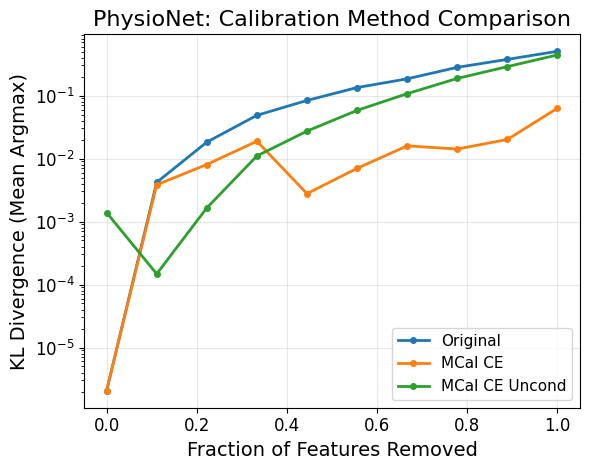


PhysioNet - Summary Statistics (Mean KL Divergence across all fractions):
Original       : 0.163171
MCal CE        : 0.015364
MCal CE Uncond : 0.112302


In [28]:
# Plot PhysioNet results
plt.figure(figsize=(6, 4.8))

for label, values in physionet_data.items():
    plt.plot(fractions, values, marker='o', label=label, linewidth=2, markersize=4)

plt.xlabel('Fraction of Features Removed', fontsize=14)
plt.ylabel('KL Divergence (Mean Argmax)', fontsize=14)
plt.title('PhysioNet: Calibration Method Comparison', fontsize=16)
plt.yscale('log')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

# Summary statistics
print("\nPhysioNet - Summary Statistics (Mean KL Divergence across all fractions):")
print("="*60)
for label, values in physionet_data.items():
    mean_kl = np.mean(values)
    print(f"{label:15s}: {mean_kl:.6f}")

## Language Modality

### MedQA Dataset

In [29]:
# Load MedQA results
with open('../results/json/aggregated_results_medqa.json', 'r') as f:
    medqa_results = json.load(f)

# Define method names and labels for MedQA
medqa_methods = {
    'baseline': 'Original',
    'mcal_ce': 'MCal CE',
    'mcal_ce_uncond': 'MCal CE Uncond'
}

# Extract data for each method
medqa_data = {}
for key, label in medqa_methods.items():
    if key in medqa_results:
        if key == 'baseline':
            medqa_data[label] = medqa_results[key]['fraction_wise_results']['mean_argmax']
        else:
            medqa_data[label] = medqa_results[key]['fraction_wise_results_transformed']['mean_argmax']

# Create x-axis (fraction values)
n_points = len(next(iter(medqa_data.values())))
fractions = np.linspace(0, 1, n_points)

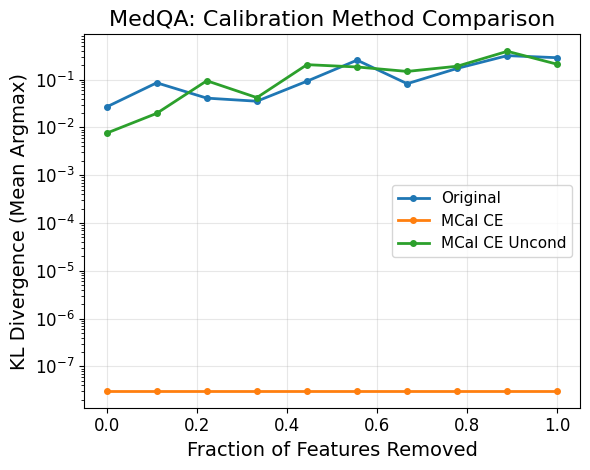


MedQA - Summary Statistics (Mean KL Divergence across all fractions):
Original       : 0.139459
MCal CE        : 0.000000
MCal CE Uncond : 0.149139


In [30]:
# Plot MedQA results
plt.figure(figsize=(6, 4.8))

for label, values in medqa_data.items():
    plt.plot(fractions, values, marker='o', label=label, linewidth=2, markersize=4)

plt.xlabel('Fraction of Features Removed', fontsize=14)
plt.ylabel('KL Divergence (Mean Argmax)', fontsize=14)
plt.title('MedQA: Calibration Method Comparison', fontsize=16)
plt.yscale('log')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

# Summary statistics
print("\nMedQA - Summary Statistics (Mean KL Divergence across all fractions):")
print("="*60)
for label, values in medqa_data.items():
    mean_kl = np.mean(values)
    print(f"{label:15s}: {mean_kl:.6f}")

## Overall Summary

Comparison across all datasets and modalities.

In [31]:
# Create a comprehensive summary table
print("\n" + "="*80)
print("COMPREHENSIVE SUMMARY: Mean KL Divergence Across All Datasets")
print("="*80)

all_datasets = [
    ('Brain MRI', mri_data),
    ('BreakHis', breakhis_data if breakhis_data else {}),
    ('CheXpert', chexpert_data if chexpert_data else {}),
    ('PhysioNet', physionet_data),
    ('MedQA', medqa_data)
]

for dataset_name, dataset_data in all_datasets:
    if dataset_data:
        print(f"\n{dataset_name}:")
        print("-" * 60)
        for label, values in dataset_data.items():
            mean_kl = np.mean(values)
            print(f"  {label:20s}: {mean_kl:.6f}")


COMPREHENSIVE SUMMARY: Mean KL Divergence Across All Datasets

Brain MRI:
------------------------------------------------------------
  Original            : 0.122491
  Replace             : 0.150789
  PatchCutout         : 0.000424
  Platt               : 0.132623
  Arch Mod            : 0.136143
  MCal CE             : 0.018525

BreakHis:
------------------------------------------------------------
  Platt               : 0.148621

CheXpert:
------------------------------------------------------------
  Original            : 0.169003
  Replace             : 0.092620
  PatchCutout         : 0.029377
  Temperature         : 0.168969
  Platt               : 0.180184
  Arch Mod            : 0.147105
  MCal CE             : 0.008458

PhysioNet:
------------------------------------------------------------
  Original            : 0.163171
  MCal CE             : 0.015364
  MCal CE Uncond      : 0.112302

MedQA:
------------------------------------------------------------
  Original       